# AcadWatch — Student Dropout Risk Prediction

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dropout_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (4424, 30)


,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 1st sem (approved),Tuition fees up to date,Curricular units 1st sem (grade),Age at enrollment,Admission grade,Curricular units 2nd sem (evaluations),Previous qualification (grade),Course,...,Curricular units 1st sem (enrolled),Previous qualification,Displaced,Curricular units 2nd sem (without evaluations),Curricular units 1st sem (without evaluations),Inflation rate,Unemployment rate,Gender,Application order,Target
0,0,0.000000,0,1,0.000000,20,127.3,0,122.0,171,...,0,1,1,0,0,1.4,10.8,1,5,Dropout
1,6,13.666667,6,0,14.000000,19,142.5,6,160.0,9254,...,6,1,1,0,0,-0.3,13.9,1,1,Non-Dropout
2,0,0.000000,0,0,0.000000,19,124.8,0,122.0,9070,...,6,1,1,0,0,1.4,10.8,1,5,Dropout
3,5,12.400000,6,1,13.428571,20,119.6,10,122.0,9773,...,6,1,1,0,0,-0.8,9.4,0,2,Non-Dropout
4,6,13.000000,5,1,12.333333,45,141.5,6,100.0,8014,...,6,1,0,0,0,-0.3,13.9,0,1,Non-Dropout


In [2]:
print('Columns:', df.columns.tolist())
print('\nNull values:\n', df.isnull().sum().sum(), 'total nulls')
print('Duplicates:', df.duplicated().sum())
print('\nTarget distribution:\n', df['Target'].value_counts())

Columns: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Tuition fees up to date', 'Curricular units 1st sem (grade)', 'Age at enrollment', 'Admission grade', 'Curricular units 2nd sem (evaluations)', 'Previous qualification (grade)', 'Course', 'Curricular units 1st sem (evaluations)', "Father's occupation", "Mother's occupation", 'GDP', 'Application mode', "Mother's qualification", "Father's qualification", 'Scholarship holder', 'Debtor', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (enrolled)', 'Previous qualification', 'Displaced', 'Curricular units 2nd sem (without evaluations)', 'Curricular units 1st sem (without evaluations)', 'Inflation rate', 'Unemployment rate', 'Gender', 'Application order', 'Target']

Null values:
 0 total nulls
Duplicates: 0

Target distribution:
 Target
Non-Dropout    3003
Dropout        1421
Name: count, dtype: int64


## 2. EDA — 5 Visuals

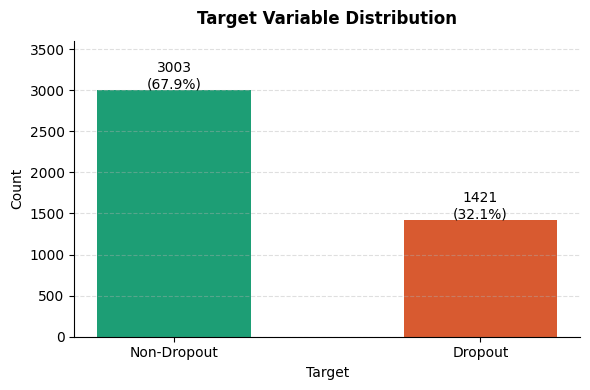

Insight: Dataset is imbalanced — 68% Non-Dropout, 32% Dropout. SMOTE will be applied on training set to address this.


In [18]:
# ── Visual 1: Target Variable Distribution ──
counts = df['Target'].value_counts()
colors = ['#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Variable Distribution', fontweight='bold', pad=12)
ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Dataset is imbalanced — 68% Non-Dropout, 32% Dropout. SMOTE will be applied on training set to address this.')

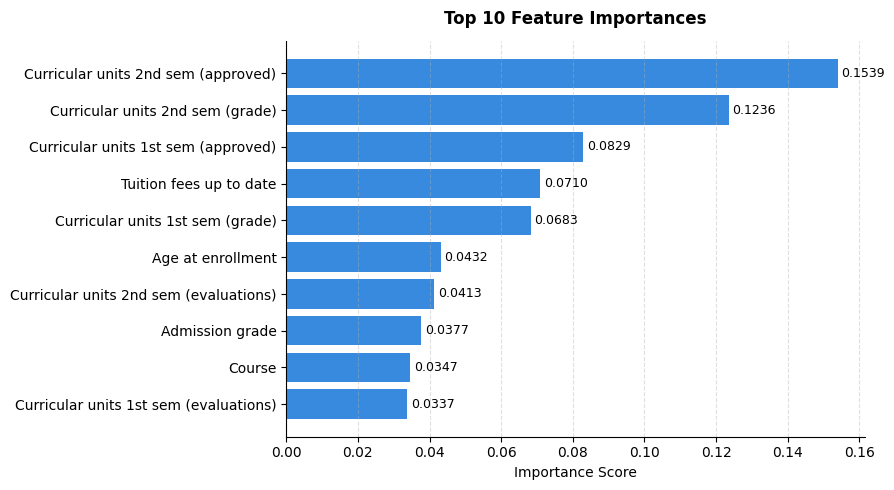

Insight: Curricular units 2nd sem (approved) is the strongest predictor — students failing to complete units are most at risk of dropping out.


In [19]:
# ── Visual 2: Top 10 Feature Importances ──
from sklearn.ensemble import RandomForestClassifier

X_eda = df.drop('Target', axis=1)
y_eda = (df['Target'] == 'Dropout').astype(int)

rf_eda = RandomForestClassifier(n_estimators=100, random_state=42)
rf_eda.fit(X_eda, y_eda)

feat_imp = pd.Series(rf_eda.feature_importances_, index=X_eda.columns).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp.index, feat_imp.values, color='#378ADD', edgecolor='none')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Top 10 Feature Importances', fontweight='bold', pad=12)
ax.set_xlabel('Importance Score')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Curricular units 2nd sem (approved) is the strongest predictor — students failing to complete units are most at risk of dropping out.')

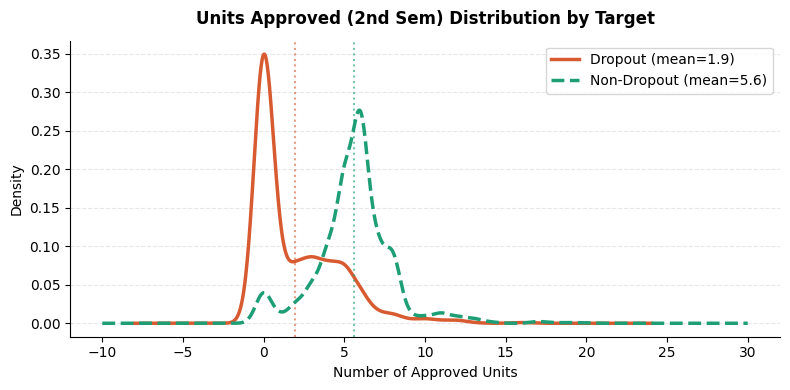

Insight: Dropout students approve significantly fewer units in 2nd semester, confirming it as the strongest predictor of dropout risk.


In [20]:
# ── Visual 3: Curricular Units 2nd Sem (Approved) — KDE by Target ──
fig, ax = plt.subplots(figsize=(8, 4))

for label, color, ls in zip(['Dropout', 'Non-Dropout'], ['#D85A30', '#1D9E75'], ['-', '--']):
    subset = df[df['Target'] == label]['Curricular units 2nd sem (approved)']
    subset.plot(kind='kde', ax=ax, label=f'{label} (mean={subset.mean():.1f})',
                color=color, linewidth=2.5, linestyle=ls)
    ax.axvline(subset.mean(), color=color, linestyle=':', alpha=0.6, linewidth=1.5)

ax.set_title('Units Approved (2nd Sem) Distribution by Target', fontweight='bold', pad=12)
ax.set_xlabel('Number of Approved Units')
ax.set_ylabel('Density')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('03_units_approved_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Dropout students approve significantly fewer units in 2nd semester, confirming it as the strongest predictor of dropout risk.')

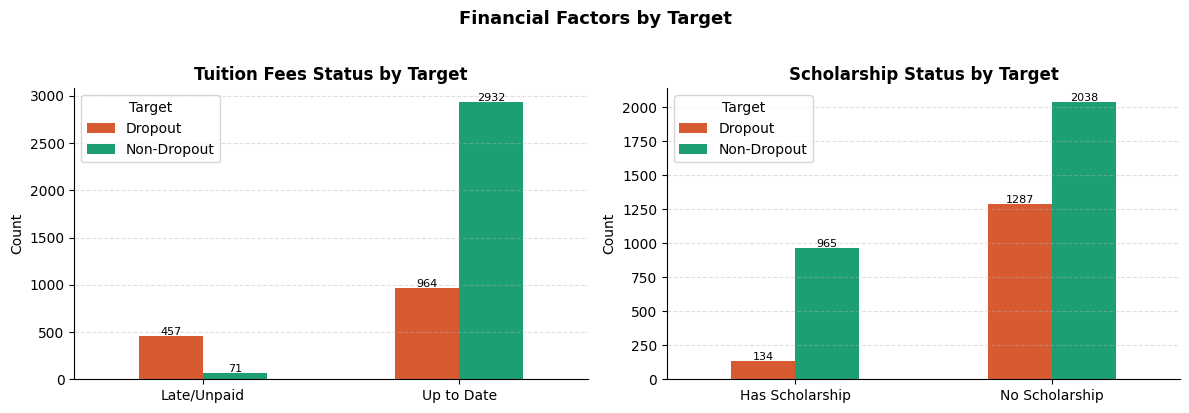

Insight: Students with late/unpaid tuition have an ~87% dropout rate. Scholarship holders rarely drop out — only 134 dropouts vs 965 non-dropouts.


In [21]:
# ── Visual 4: Tuition Fees & Scholarship Status by Target ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tuition fees
tuition_ct = pd.crosstab(df['Tuition fees up to date'].map({0: 'Late/Unpaid', 1: 'Up to Date'}), df['Target'])
tuition_ct.plot(kind='bar', ax=axes[0], color=['#D85A30', '#1D9E75'], edgecolor='none', rot=0)
axes[0].set_title('Tuition Fees Status by Target', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10),
                     ha='center', fontsize=8)

# Scholarship
schol_ct = pd.crosstab(df['Scholarship holder'].map({0: 'No Scholarship', 1: 'Has Scholarship'}), df['Target'])
schol_ct.plot(kind='bar', ax=axes[1], color=['#D85A30', '#1D9E75'], edgecolor='none', rot=0)
axes[1].set_title('Scholarship Status by Target', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10),
                     ha='center', fontsize=8)

fig.suptitle('Financial Factors by Target', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('04_financial_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Students with late/unpaid tuition have an ~87% dropout rate. Scholarship holders rarely drop out — only 134 dropouts vs 965 non-dropouts.')

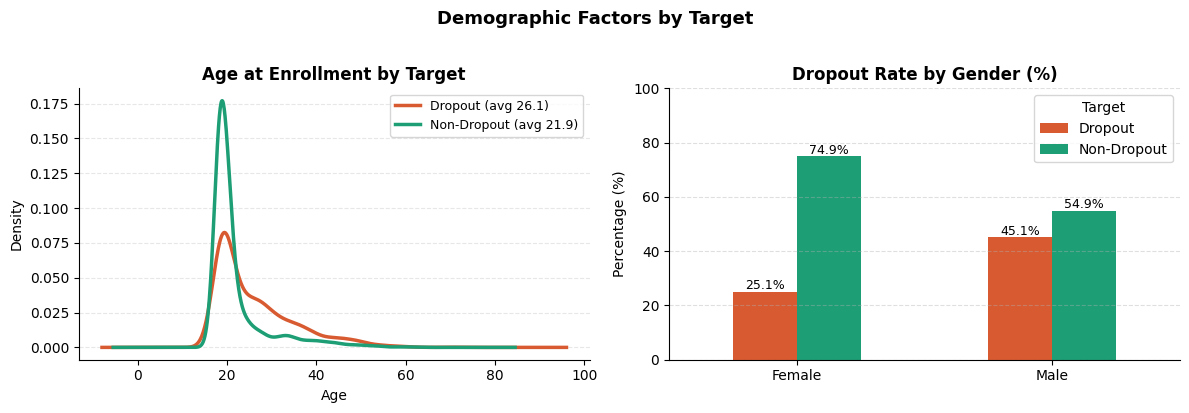

Insight: Dropout students enroll older on average (26.1 vs 21.9 yrs). Male students have a ~45% dropout rate vs ~25% for females.


In [22]:
# ── Visual 5: Age at Enrollment & Gender by Target ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution KDE
for label, color in zip(['Dropout', 'Non-Dropout'], ['#D85A30', '#1D9E75']):
    subset = df[df['Target'] == label]['Age at enrollment']
    subset.plot(kind='kde', ax=axes[0], label=f'{label} (avg {subset.mean():.1f})',
                color=color, linewidth=2.5)
axes[0].set_title('Age at Enrollment by Target', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Gender grouped bar
gender_ct = pd.crosstab(df['Gender'].map({0: 'Female', 1: 'Male'}), df['Target'])
gender_pct = gender_ct.div(gender_ct.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[1], color=['#D85A30', '#1D9E75'], edgecolor='none', rot=0)
axes[1].set_title('Dropout Rate by Gender (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].set_ylim(0, 100)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=9)

fig.suptitle('Demographic Factors by Target', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('05_demographic_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Dropout students enroll older on average (26.1 vs 21.9 yrs). Male students have a ~45% dropout rate vs ~25% for females.')

## 3. Preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Label encoding
X = df.drop(columns=['Target'])
y = (df['Target'] == 'Dropout').astype(int)  # 1 = Dropout, 0 = Non-Dropout

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler — fit on train only to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape: ', X_test_scaled.shape)
print('\nTrain class distribution:')
print(pd.Series(y_train).value_counts())

Train shape: (3539, 29)
Test shape:  (885, 29)

Train class distribution:
Target
0    2402
1    1137
Name: count, dtype: int64


In [9]:
# SMOTE — applied on training set only
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', pd.Series(y_train).value_counts().to_dict())
print('After SMOTE: ', pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 2402, 1: 1137}
After SMOTE:  {1: 2402, 0: 2402}


## 4. Model Comparison — SMOTE + 5-Fold Stratified CV

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Naive Bayes':         GaussianNB()
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_validate(model, X_train_sm, y_train_sm, cv=skf,
                            scoring=['accuracy', 'precision_weighted',
                                     'recall_weighted', 'f1_weighted'])
    cv_results[name] = {
        'CV Accuracy':  scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision_weighted'].mean(),
        'CV Recall':    scores['test_recall_weighted'].mean(),
        'CV F1 Score':  scores['test_f1_weighted'].mean()
    }

cv_df = pd.DataFrame(cv_results).T.sort_values('CV F1 Score', ascending=False)
print('=== CV Results (SMOTE + 5-Fold Stratified CV) ===')
print(cv_df.round(4).to_string())

top2_models = cv_df.head(2).index.tolist()
print(f'\nTop 2 Models: {top2_models}')

=== CV Results (SMOTE + 5-Fold Stratified CV) ===
                     CV Accuracy  CV Precision  CV Recall  CV F1 Score
Random Forest             0.9045        0.9053     0.9045       0.9044
KNN                       0.8528        0.8547     0.8528       0.8526
Logistic Regression       0.8503        0.8531     0.8503       0.8500
Decision Tree             0.8389        0.8390     0.8389       0.8389
Naive Bayes               0.7975        0.8061     0.7975       0.7960

Top 2 Models: ['Random Forest', 'KNN']


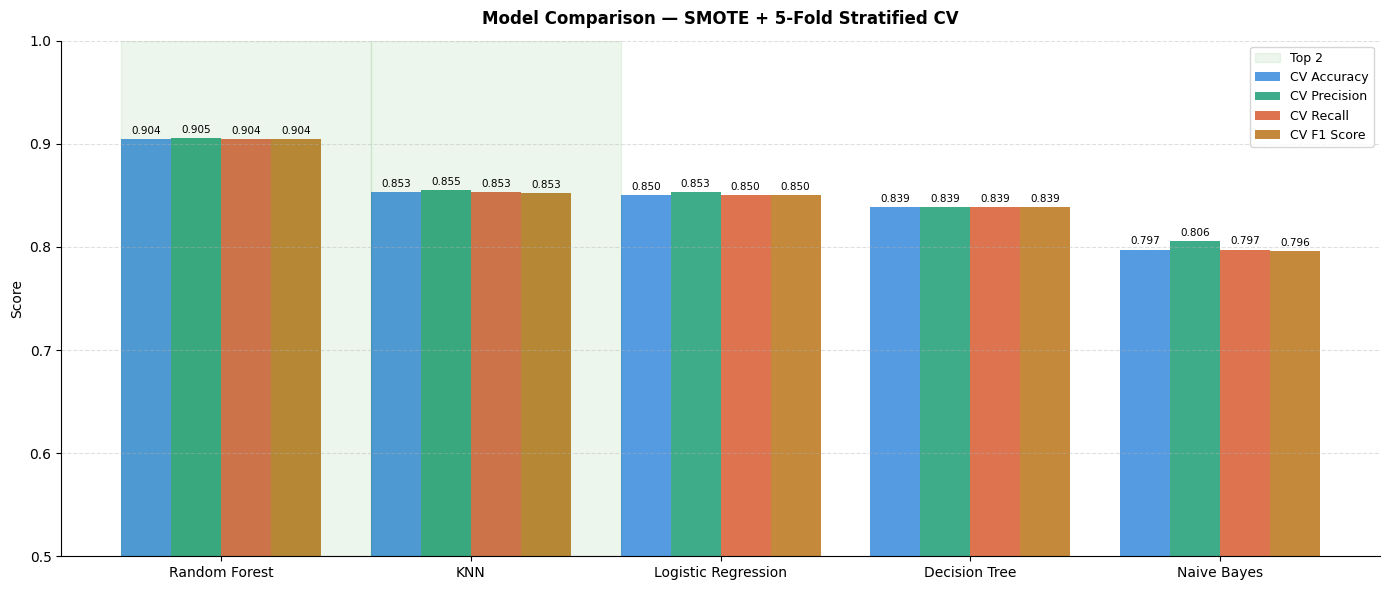

In [11]:
# Bar chart — CV results
metrics = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1 Score']
colors  = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517']
x = np.arange(len(cv_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, cv_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='none')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# Highlight top 2
for rank in range(2):
    ax.axvspan(rank - 0.1, rank + 4 * width + 0.1,
               alpha=0.07, color='green',
               label='Top 2' if rank == 0 else '_nolegend_')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cv_df.index, fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — SMOTE + 5-Fold Stratified CV', fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hyperparameter Tuning — Top 2 Models

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators':      [100, 200, 300],
            'max_depth':         [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf':  [1, 2, 4],
            'max_features':      ['sqrt', 'log2']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights':     ['uniform', 'distance'],
            'metric':      ['euclidean', 'manhattan', 'minkowski'],
            'p':           [1, 2]
        }
    }
}

tuned_estimators = {}
tuning_summary = {}

for name in top2_models:
    if name not in param_grids:
        print(f'No param grid defined for {name}, skipping.')
        continue

    pg = param_grids[name]
    search = RandomizedSearchCV(
        pg['model'], pg['params'],
        n_iter=20, cv=skf,
        scoring='recall_weighted',
        random_state=42, n_jobs=-1, verbose=1
    )
    search.fit(X_train_sm, y_train_sm)

    tuned_estimators[name] = search.best_estimator_
    tuning_summary[name] = {
        'Best Params': search.best_params_,
        'Best CV Recall': round(search.best_score_, 4)
    }

    print(f'\n=== {name} Best Params ===')
    print(search.best_params_)
    print(f'Best Recall (CV): {search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Random Forest Best Params ===
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best Recall (CV): 0.9057
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== KNN Best Params ===
{'weights': 'distance', 'p': 1, 'n_neighbors': 3, 'metric': 'minkowski'}
Best Recall (CV): 0.8990


## 6. Evaluation — Compare Tuned Models on Test Set

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              RocCurveDisplay, classification_report)

eval_results = {}

for name, model in tuned_estimators.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    eval_results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    }

eval_df = pd.DataFrame(eval_results).T.sort_values('Recall', ascending=False)
print('=== Tuned Model Comparison on Test Set ===')
print(eval_df.to_string())

# Pick best model by Recall
best_model_name = eval_df['Recall'].idxmax()
best_model = tuned_estimators[best_model_name]
print(f'\n✅ Chosen Model: {best_model_name} (highest Recall)')

=== Tuned Model Comparison on Test Set ===
               Accuracy  Precision  Recall  F1 Score  ROC-AUC
Random Forest    0.8825     0.8811  0.8825    0.8809   0.9315
KNN              0.8249     0.8238  0.8249    0.8243   0.8555

✅ Chosen Model: Random Forest (highest Recall)


In [14]:
# Final evaluation of chosen model
y_pred_final = best_model.predict(X_test_scaled)
y_prob_final = best_model.predict_proba(X_test_scaled)[:, 1]

print(f'=== {best_model_name} — Final Test Set Evaluation ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_final, average="weighted"):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_final, average="weighted"):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Non-Dropout', 'Dropout']))

=== Random Forest — Final Test Set Evaluation ===
Accuracy:  0.8825
Precision: 0.8811
Recall:    0.8825
F1 Score:  0.8809
ROC-AUC:   0.9315

              precision    recall  f1-score   support

 Non-Dropout       0.90      0.94      0.92       601
     Dropout       0.85      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



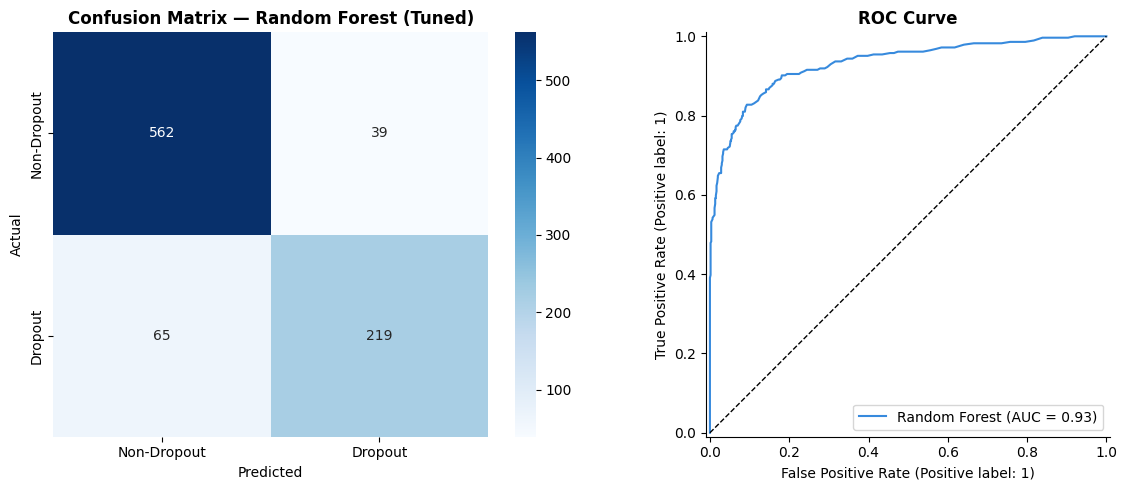

In [15]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Dropout', 'Dropout'],
            yticklabels=['Non-Dropout', 'Dropout'])
axes[0].set_title(f'Confusion Matrix — {best_model_name} (Tuned)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[1],
                                  color='#378ADD', name=best_model_name)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Before vs After Tuning comparison
before_after = {}
for name in top2_models:
    if name in cv_results and name in eval_results:
        before_after[name] = {
            'Before (CV F1)': round(cv_results[name]['CV F1 Score'], 4),
            'After (Test F1)': eval_results[name]['F1 Score'],
            'Before (CV Recall)': round(cv_results[name]['CV Recall'], 4),
            'After (Test Recall)': eval_results[name]['Recall']
        }

print('=== Before vs After Hypertuning ===')
print(pd.DataFrame(before_after).T.to_string())

=== Before vs After Hypertuning ===
               Before (CV F1)  After (Test F1)  Before (CV Recall)  After (Test Recall)
Random Forest          0.9044           0.8809              0.9045               0.8825
KNN                    0.8526           0.8243              0.8528               0.8249


## 7. Save Best Model as PKL

In [17]:
import pickle

# Save scaler + best tuned model together
pipeline = {
    'model_name': best_model_name,
    'scaler':     scaler,
    'model':      best_model
}

with open('dropout_model.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print(f'Model saved as dropout_model.pkl')
print(f'Model: {best_model_name}')

# Verify load
with open('dropout_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

test_pred = loaded['model'].predict(loaded['scaler'].transform(X_test))
print('Load verification accuracy:', round(accuracy_score(y_test, test_pred), 4))
print('✅ PKL saved and verified successfully.')

Model saved as dropout_model.pkl
Model: Random Forest
Load verification accuracy: 0.8825
✅ PKL saved and verified successfully.
